# 227. Basic Calculator II
https://leetcode.com/problems/basic-calculator-ii/

## Complexity Comparison

| Approach | Time | Space | Notes |
|----------|------|-------|-------|
| Stack-based | $O(n)$ | $O(n)$ | Process operators by precedence |
| No stack (track prev) | $O(n)$ | $O(1)$ | Optimal space |

## Methodology

Use a stack to handle operator precedence. Scan left to right, building numbers. When hitting an operator or end of string: if previous operator was `+` or `-`, push the number (negated for `-`). If `*` or `/`, pop the top, apply the operation, and push the result. Finally sum the stack. This correctly handles precedence since `*` and `/` are applied immediately while `+` and `-` are deferred.

## Solutions

### C#

In [ ]:
public class Solution {
    public int Calculate(string s) {
        var stack = new Stack<int>();
        int num = 0;
        char op = '+';
        for (int i = 0; i < s.Length; i++) {
            char c = s[i];
            if (char.IsDigit(c))
                num = num * 10 + (c - '0');
            if ((!char.IsDigit(c) && c != ' ') || i == s.Length - 1) {
                switch (op) {
                    case '+': stack.Push(num); break;
                    case '-': stack.Push(-num); break;
                    case '*': stack.Push(stack.Pop() * num); break;
                    case '/': stack.Push(stack.Pop() / num); break;
                }
                op = c;
                num = 0;
            }
        }
        int result = 0;
        foreach (int val in stack) result += val;
        return result;
    }
}

### Python

In [ ]:
class Solution:
    def calculate(self, s: str) -> int:
        stack = []
        num = 0
        op = '+'
        for i, c in enumerate(s):
            if c.isdigit():
                num = num * 10 + int(c)
            if (not c.isdigit() and c != ' ') or i == len(s) - 1:
                if op == '+':
                    stack.append(num)
                elif op == '-':
                    stack.append(-num)
                elif op == '*':
                    stack.append(stack.pop() * num)
                elif op == '/':
                    stack.append(int(stack.pop() / num))
                op = c
                num = 0
        return sum(stack)

### Go

In [ ]:
func calculate(s string) int {
    stack := []int{}
    num := 0
    op := byte('+')
    for i := 0; i < len(s); i++ {
        c := s[i]
        if c >= '0' && c <= '9' {
            num = num*10 + int(c-'0')
        }
        if (c < '0' || c > '9') && c != ' ' || i == len(s)-1 {
            switch op {
            case '+':
                stack = append(stack, num)
            case '-':
                stack = append(stack, -num)
            case '*':
                stack[len(stack)-1] *= num
            case '/':
                stack[len(stack)-1] /= num
            }
            op = c
            num = 0
        }
    }
    result := 0
    for _, v := range stack {
        result += v
    }
    return result
}

### Rust

In [ ]:
impl Solution {
    pub fn calculate(s: String) -> i32 {
        let mut stack: Vec<i32> = Vec::new();
        let mut num: i32 = 0;
        let mut op = b'+';
        let bytes = s.as_bytes();
        for i in 0..bytes.len() {
            let c = bytes[i];
            if c.is_ascii_digit() {
                num = num * 10 + (c - b'0') as i32;
            }
            if (!c.is_ascii_digit() && c != b' ') || i == bytes.len() - 1 {
                match op {
                    b'+' => stack.push(num),
                    b'-' => stack.push(-num),
                    b'*' => { let top = stack.pop().unwrap(); stack.push(top * num); }
                    b'/' => { let top = stack.pop().unwrap(); stack.push(top / num); }
                    _ => {}
                }
                op = c;
                num = 0;
            }
        }
        stack.iter().sum()
    }
}

## Example Scenarios

1. **Common Case** — Mixed addition and multiplication  
   **Input:** `s = "3+2*2"`  
   Scan left to right: push $+3$, see `*` so compute $2 \times 2 = 4$ and push $+4$. Stack = $[3, 4]$. Sum = $7$.

2. **Slightly Complex** — All four operators with spaces  
   **Input:** `s = " 14 - 3/2 + 5*3 "`  
   Parse: push $+14$, push $-3$, see `/` → pop $-3$, but we track sign separately: $3/2=1$, push $-1$. See `*` → $5 \times 3=15$, push $+15$. Stack = $[14, -1, 15]$. Sum = $28$.

3. **Edge Case: Time Factor** — Maximum-length expression ($3 \times 10^5$ chars)  
   **Input:** `s = "1+1+1+...+1"` (150,000 additions)  
   Every character is scanned once in $O(n)$. The stack grows to 150,000 entries — all additions, no multiplication/division to reduce. Tests the upper bound of the single-pass approach.

4. **Edge Case: Space Factor** — Single number, no operators  
   **Input:** `s = "2147483647"`  
   Only one number is parsed ($2^{31}-1$). Stack holds exactly one element. Tests $O(1)$ space and integer overflow boundary — the result fits in a 32-bit signed int.

5. **Almost-Impossible but Plausible** — Chain of divisions reducing to zero  
   **Input:** `s = "1000000/3/3/3/3/3/3/3/3/3/3/3/3"`  
   Integer truncation cascades: $1000000 \to 333333 \to 111111 \to \cdots \to 0$. After enough divisions the value floors to $0$ and stays there. Tests truncation-toward-zero semantics across 12 consecutive divisions.

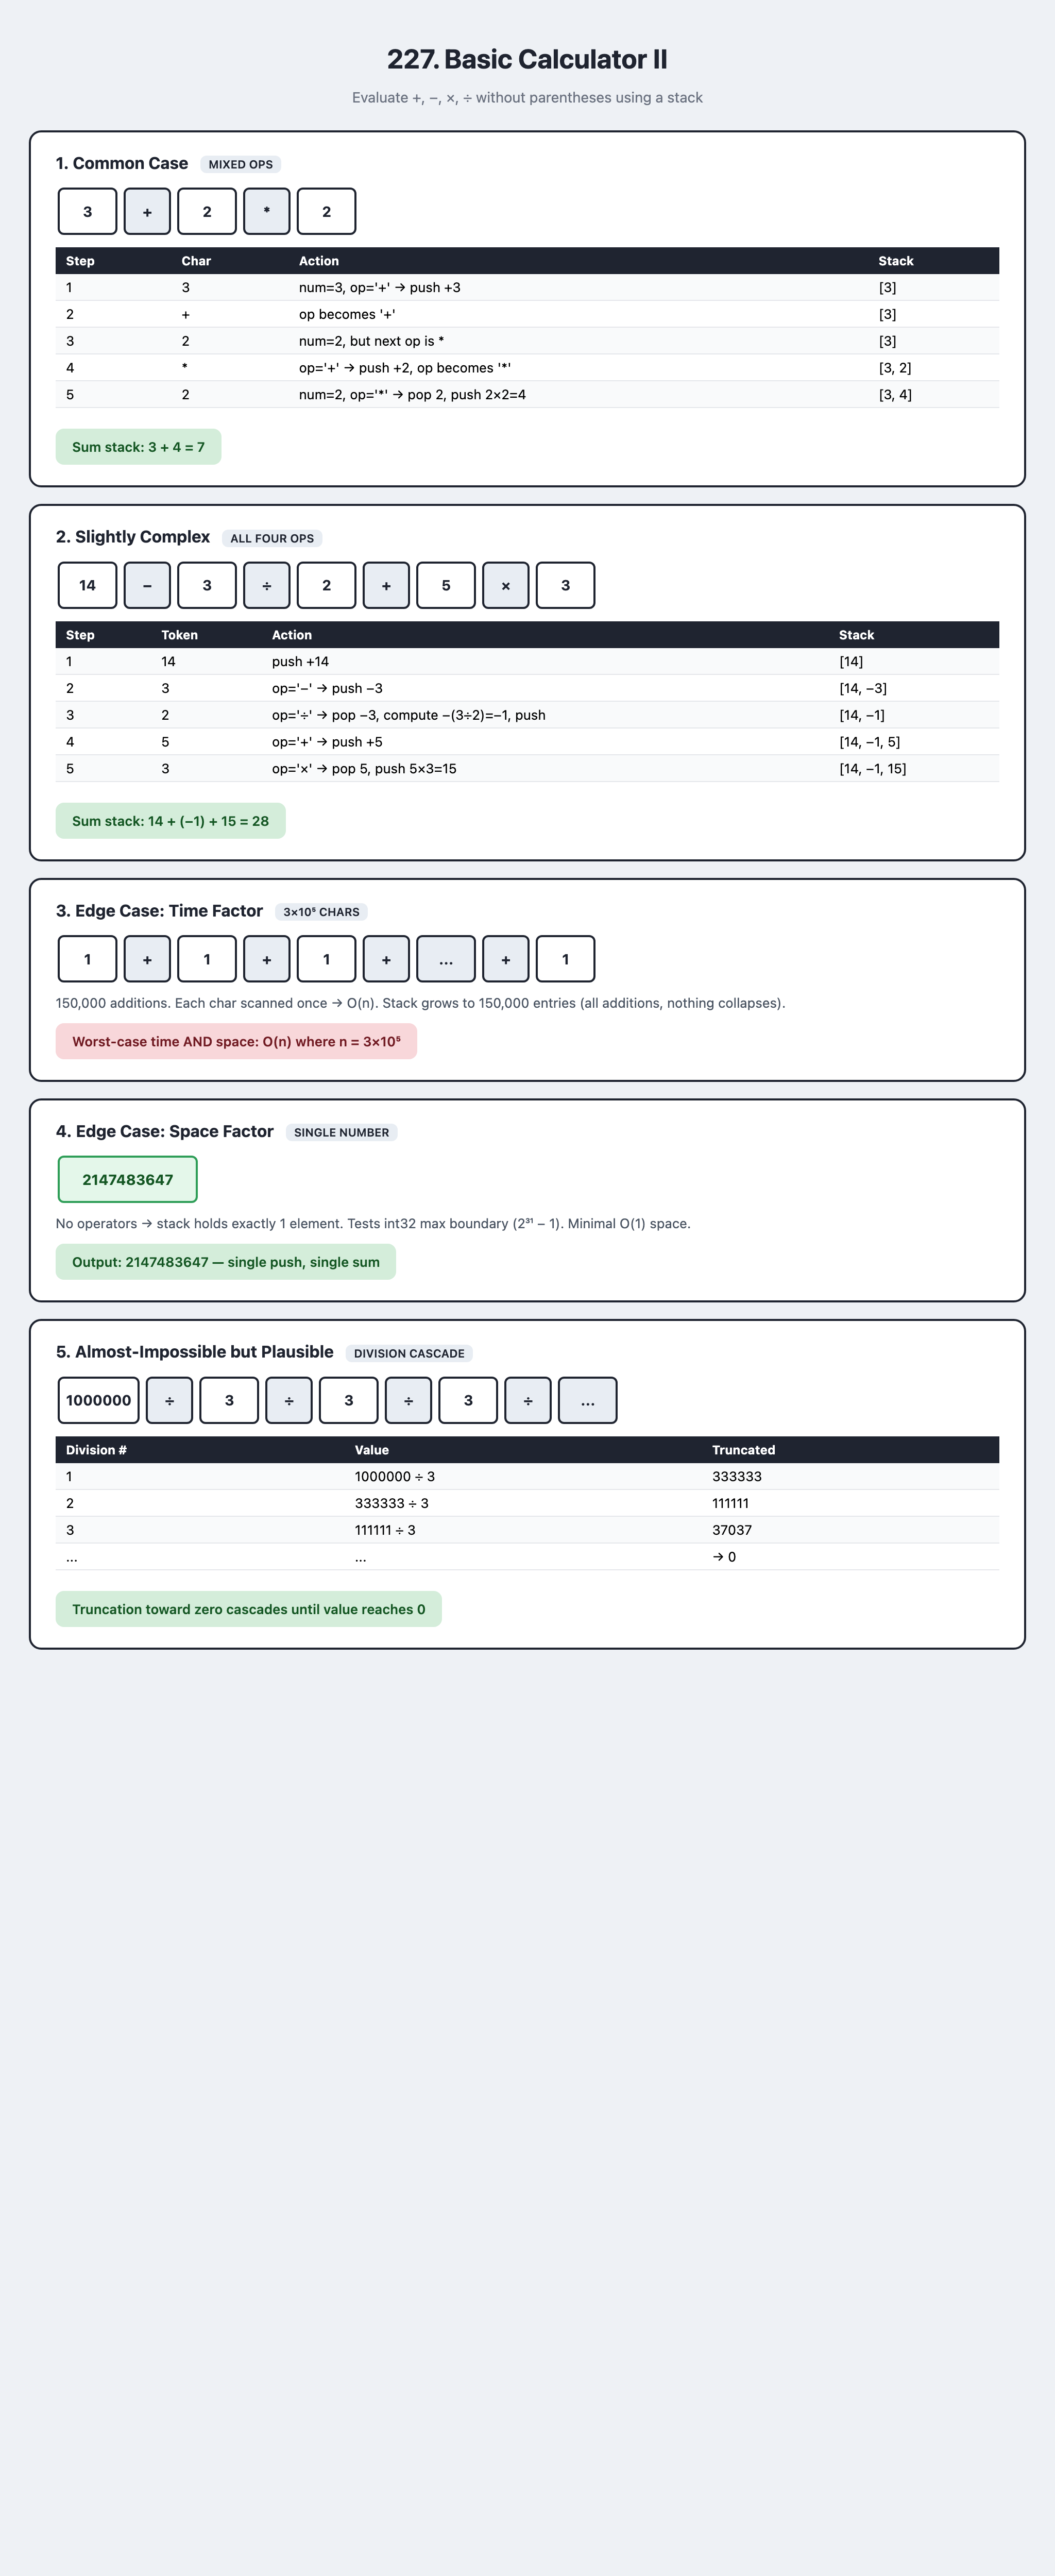